# 08 · Merged analyzers: full-year QC fluxes

The two analyzers cover complementary halves of 2021: the QCL runs in campaign
2021_1 (January to 20 July) and the LGR in campaign 2021_2 (22 July to December).
Concatenating them over time gives one continuous **full-year** series per
variant. This notebook merges the two and plots the merged, quality-controlled
flux for the whole of 2021.

Fluxes are the USTAR-filtered QC fluxes from the flux processing chain
([notebook 05](05_flux_processing_chain.ipynb)); the merge just stitches the QCL
and LGR halves together at the campaign boundary (a light dashed line marks the
handover).

Two figures are produced, one per gas:

- **N2O:** the five variants as columns, each a merged full-year series, with the
  QC flux (top), the merged time lag used (middle), and a histogram of that lag
  (bottom). Saved as `figures/08_{scenario}_merged_n2o.png`.
- **CH4:** the same, for methane. Saved as `figures/08_{scenario}_merged_ch4.png`.

Inputs:
- `data/05-flux_processing_chain_parquet/` for the QC fluxes.
- `data/02-…_subsets/` and `data/01-pwb_tlag_summary_parquet/` for the time lag
  (the chain output does not carry it).

## Imports

In [26]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

`USTAR_SCENARIO` selects which of the three USTAR-filtered fluxes to plot. The
five variants are the columns; each column is the QCL half and the LGR half of
that variant merged into one full-year series. The lag for variants `*-1` to
`*-4` is the EddyPro time lag used, while the PWB column (`*-5`) uses its detected
lag. The constant-lag variant (`*-4`) carries two constants here, one per
campaign, so it gets a histogram like the others rather than a single-value note.

In [27]:
FPCDIR = Path("../data/05-flux_processing_chain_parquet")              # QC fluxes
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")  # lag, *-1..*-4
PWBDIR = Path("../data/01-pwb_tlag_summary_parquet")                   # lag, *-5
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

YEAR = 2021
USTAR_SCENARIO = "CUT_50"  # one of CUT_16 / CUT_50 / CUT_84

FIGSIZE = (16, 9)
DPI = 300

# The two analyzers cover complementary halves of the year; QCL is the earlier
# campaign (plotted first), LGR the later one.
ANALYZERS = ["QCL", "LGR"]
# Columns = the five time-lag variants; each is merged across both analyzers.
VARIANTS = [1, 2, 3, 4, 5]
PWB_VARIANT = 5  # the PWB variant uses its detected lag, not the EddyPro lag

# Column titles: what each variant does to find the time lag (see
# docs/processing-versions.md).
VARIANT_NAMES = {
    1: "Max. covariance\nwide, no default",
    2: "Max. covariance\nwide, default",
    3: "Max. covariance\nnarrow, default",
    4: "Constant lag",
    5: "PWB",
}

# Per gas: the flux variable, the EddyPro time-lag-used variable, and the PWB
# detected-lag column.
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED", "pwb_lag": "n2o_tlag_final_pf_s"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED", "pwb_lag": "ch4_tlag_final_pf_s"},
}

# One color per instrument, used across all three rows (flux, lag, histogram).
# Distinct but from neighbouring hues, so the figure stays cohesive.
INSTRUMENT_COLORS = {"QCL": "#3182bd", "LGR": "#e67e22"}  # blue, orange

# Pretty gas labels for axis text and titles.
GAS_LABEL = {"N2O": "N$_2$O", "CH4": "CH$_4$"}

BIN_S = 0.05                 # lag histogram bin width (s); EddyPro tlag grid
PCTL = (1, 99)              # robust flux y-range percentiles
SEARCH_WINDOW = (0.0, 10.0)  # covariance-maximization search window (s)
FRINGE_MARGIN = 0.1          # peak search ignores lags within this of the rails


def qc_col(fluxvar, scenario):
    """Name of the USTAR-filtered, QCF-accepted flux column in the fpc output."""
    return f"{fluxvar}_L3.1_L3.3_{scenario}_QCF"


print(f"Merging {ANALYZERS} into full-year series, USTAR scenario: {USTAR_SCENARIO}")

Merging ['QCL', 'LGR'] into full-year series, USTAR scenario: CUT_50


## Load and merge the QC fluxes and the time lag

For each analyzer, variant and gas the QC flux is pulled from its `*_fpc.parquet`
(the single `USTAR_SCENARIO` column) and the time lag from the column subsets
(`*-1` to `*-4`) or the PWB summaries (`*-5`). The two analyzers are then
concatenated over time per variant. Because the campaigns do not overlap, this is
a clean stitch: no timestamp appears in both halves.

In [28]:
def _yr(df):
    return df.loc[df.index.year == YEAR]


# Per-analyzer QC flux and lag, then merged full-year series keyed by (variant, gas).
qcflux, lag_used = {}, {}          # per (analyzer, variant, gas)
merged_flux, merged_lag = {}, {}   # per (variant, gas): full-year series
boundary = {}                       # campaign handover per analyzer pair

for var in VARIANTS:
    for analyzer in ANALYZERS:
        code = f"{analyzer}-{var}"
        # Lag source: PWB summary for the PWB variant, subset otherwise.
        if var == PWB_VARIANT:
            lagdf = _yr(load_parquet(filepath=str(PWBDIR / f"{code}_pwb_tlag.parquet")))
        else:
            lagdf = _yr(load_parquet(filepath=str(SUBSETDIR / f"{code}.parquet")))
        for gas, v in GASES.items():
            df = _yr(load_parquet(filepath=str(FPCDIR / f"{code}_{v['flux']}_fpc.parquet")))
            qcflux[(analyzer, var, gas)] = df[qc_col(v["flux"], USTAR_SCENARIO)]
            lagcol = v["pwb_lag"] if var == PWB_VARIANT else v["lag"]
            lag_used[(analyzer, var, gas)] = lagdf[lagcol]

    for gas in GASES:
        merged_flux[(var, gas)] = pd.concat(
            [qcflux[(a, var, gas)] for a in ANALYZERS]).sort_index()
        merged_lag[(var, gas)] = pd.concat(
            [lag_used[(a, var, gas)] for a in ANALYZERS]).sort_index()

# Campaign handover: midpoint between the last QCL and first LGR timestamp
# (identical across variants/gases; take it from variant 1, N2O).
_qcl_end = qcflux[("QCL", 1, "N2O")].index.max()
_lgr_start = qcflux[("LGR", 1, "N2O")].index.min()
HANDOVER = _qcl_end + (_lgr_start - _qcl_end) / 2

for var in VARIANTS:
    s = merged_flux[(var, "N2O")]
    print(f"variant -{var}: {int(s.notna().sum())} valid merged QC N2O "
          f"({s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d})")
print(f"campaign handover marked at {HANDOVER:%Y-%m-%d %H:%M}")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.134 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FN2O_fpc.parquet (0.032 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FCH4_fpc.parquet (0.029 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-1.parquet (0.021 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-1_FN2O_fpc.parquet (0.039 seconds).

...

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-5_FCH4_fpc.parquet (0.036 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\LGR-5_pwb_tlag.parquet (0.030 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FN2O_fpc.parquet (0.029 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FCH4_fpc.parquet (0.011 seconds).

variant -1: 11337 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -2: 11235 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -3: 10299 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -4: 9676 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -5: 9652 valid merged QC N2O (2021-01-01 to 2021-12-31)
campaign handover marked at 2021-07-21 13:15


## Figures: merged full-year QC flux, time lag, lag histogram

One figure per gas. Three rows (QC flux over time, time lag used over time, lag
histogram) with the five variants as columns. The two instruments carry one color
each (QCL blue, LGR yellow-orange), used consistently across all three rows; the
top-left flux panel carries the instrument legend, and a light dashed line marks
the QCL to LGR handover in the top two rows.

The bottom row stacks the two instruments' lag histograms so their distributions
can be read together per variant. The full distribution is shown, including the
pile-ups at the 0 s and 10 s search window rails (half-hours where covariance
maximization ran to the window edge, which mostly affect `*-1`). Those rails are
left unlabelled: the annotation marks each instrument's real modal (peak) lag,
found after excluding the fringe. The flux y-limits and the histogram bins are
shared across the columns; each histogram keeps its own count axis, since the
constant-lag variant (`*-4`) piles up single-value spikes that would otherwise
flatten the rest.

Saved ..\figures\08_cut_50_merged_n2o.png


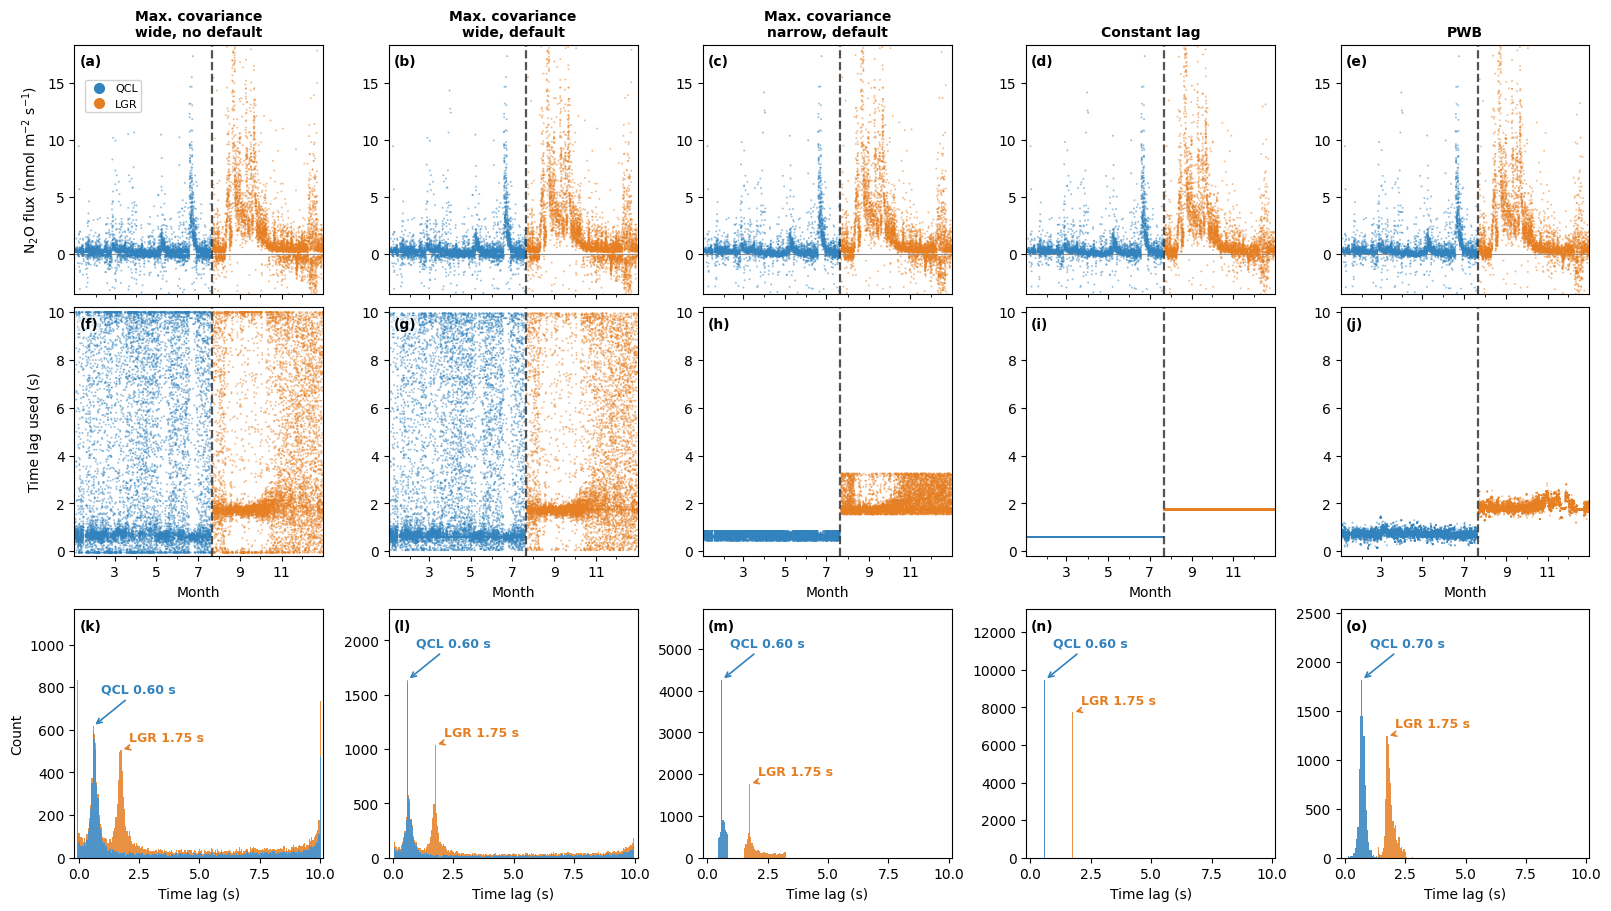

Saved ..\figures\08_cut_50_merged_ch4.png


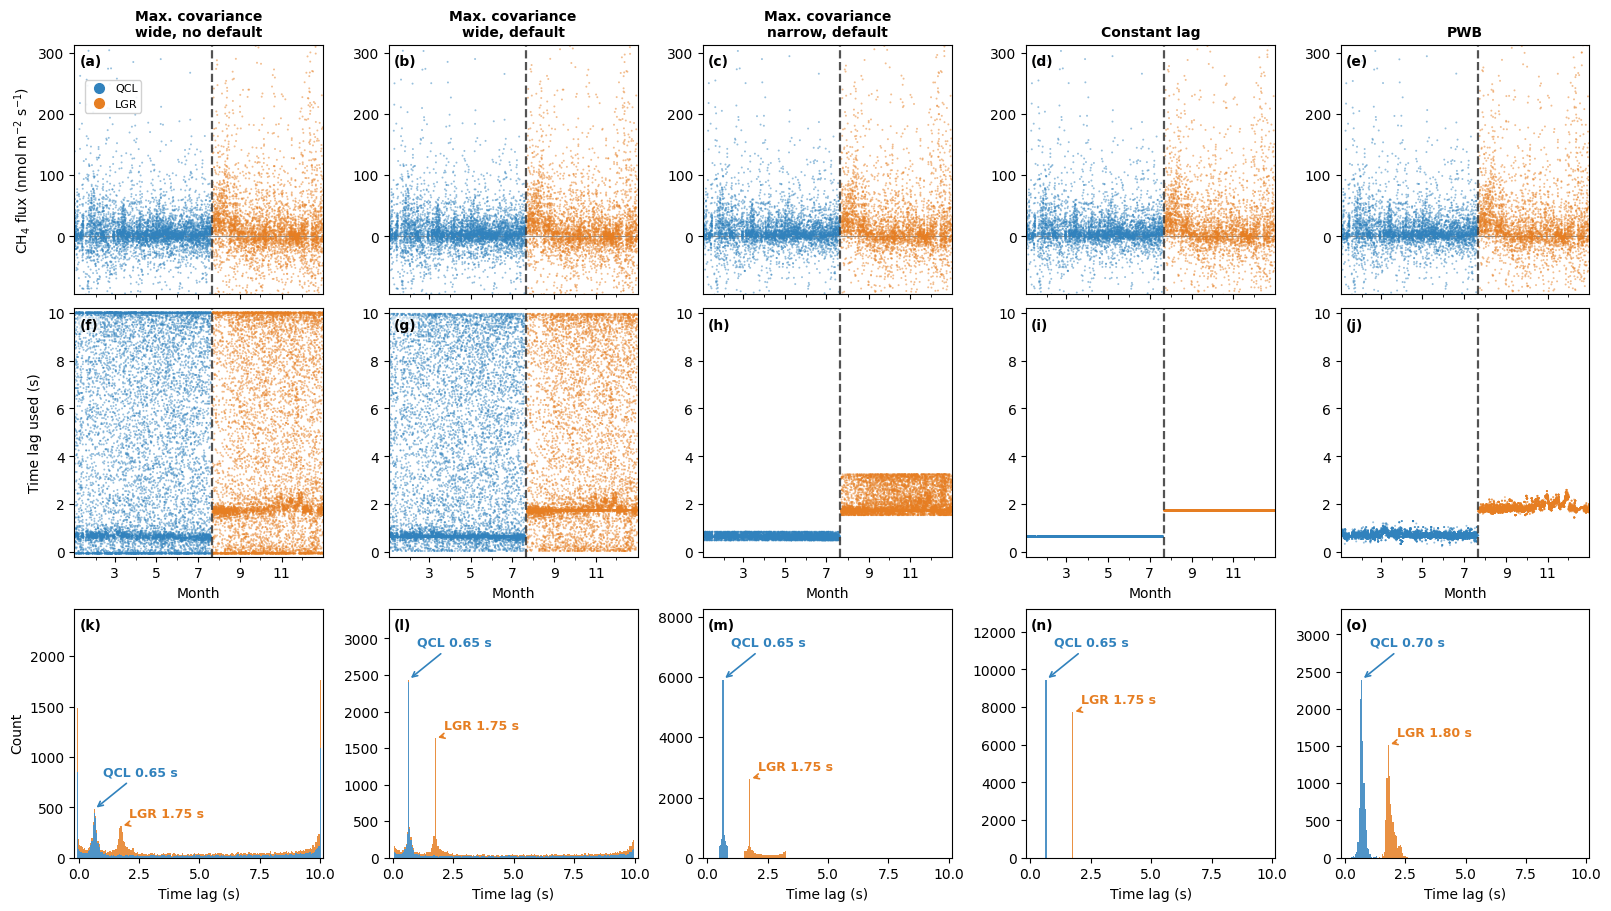

In [29]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


LAG_YLIM = (-0.2, 10.2)  # full 0 to 10 s search window with a small pad
LO_EDGE = SEARCH_WINDOW[0] + FRINGE_MARGIN
HI_EDGE = SEARCH_WINDOW[1] - FRINGE_MARGIN
MARKER_S = 2       # scatter marker size for the flux and lag rows
LETTERS = "abcdefghijklmnopqrstuvwxyz"


def month_int(x, pos):
    """Format a date tick as its (integer) month number, no year."""
    return f"{mdates.num2date(x).month}"


def panel_letter(ax, text):
    """Bold panel letter in the top-left corner, over a faint white patch."""
    ax.text(0.02, 0.96, f"({text})", transform=ax.transAxes, va="top", ha="left",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.6))


def style_axes(ax):
    """Black spines, short outward major/minor ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")
    ax.tick_params(which="minor", length=2.0, width=0.6, direction="out", color="black")


# Legend proxies for the two instruments (shown in the top-left flux panel).
inst_handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7,
                       color=INSTRUMENT_COLORS[a], label=a) for a in ANALYZERS]

for gas in GASES:
    columns = VARIANTS
    ncols = len(columns)
    glabel = GAS_LABEL[gas]

    # Robust flux range across both instruments and all variants.
    flux_vals = np.concatenate(
        [merged_flux[(var, gas)].to_numpy().ravel() for var in columns])
    flux_ylim = robust_ylim(flux_vals)

    # Histogram bins over the full lag range (including the 0 s / 10 s rails),
    # shared across columns so the distributions line up.
    all_lag = np.concatenate(
        [lag_used[(a, var, gas)].dropna().to_numpy()
         for var in columns for a in ANALYZERS])
    lo_k = int(np.floor(np.nanmin(all_lag) / BIN_S))
    hi_k = int(np.ceil(np.nanmax(all_lag) / BIN_S))
    bins = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S
    centers = 0.5 * (bins[:-1] + bins[1:])
    hist_xlim = (bins[0] - 0.1, bins[-1] + 0.1)

    # Non-fringe lags per instrument, used only to place the peak annotation.
    def inside(a, var):
        s = lag_used[(a, var, gas)].dropna()
        return s[(s > LO_EDGE) & (s < HI_EDGE)]

    fig, axes = plt.subplots(nrows=3, ncols=ncols,
                             figsize=FIGSIZE, constrained_layout=True)

    for ci, var in enumerate(columns):
        ax_flux, ax_lag, ax_hist = axes[0, ci], axes[1, ci], axes[2, ci]

        ax_lag.sharex(ax_flux)
        if ci > 0:
            ax_flux.sharey(axes[0, 0])
            ax_lag.sharey(axes[1, 0])
        for r, ax in enumerate((ax_flux, ax_lag, ax_hist)):
            style_axes(ax)
            panel_letter(ax, LETTERS[r * ncols + ci])
        ax_flux.set_title(VARIANT_NAMES[var], fontweight="bold", fontsize=10)

        # Rows 1 and 2: QC flux and time lag over time, one color per instrument.
        ax_flux.axhline(0, color="0.55", lw=0.8, zorder=0.5)  # zero reference
        for a in ANALYZERS:
            c = INSTRUMENT_COLORS[a]
            f = qcflux[(a, var, gas)].dropna()
            ax_flux.scatter(f.index, f, s=MARKER_S, alpha=0.5, color=c, edgecolors="none")
            lg = lag_used[(a, var, gas)].dropna()
            ax_lag.scatter(lg.index, lg, s=MARKER_S, alpha=0.5, color=c, edgecolors="none")
        for ax in (ax_flux, ax_lag):
            ax.axvline(HANDOVER, color="0.25", lw=1.6, ls="--", alpha=0.9)
        ax_flux.set_ylim(flux_ylim)
        ax_flux.tick_params(labelbottom=False)
        ax_lag.set_ylim(*LAG_YLIM)
        # Time axis: integer month numbers as major ticks (no year), an unlabelled
        # minor tick at every month, and a "Month" axis label.
        ax_lag.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax_lag.xaxis.set_major_formatter(mticker.FuncFormatter(month_int))
        ax_lag.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
        ax_lag.set_xlabel("Month")
        span = merged_lag[(var, gas)].index
        ax_lag.set_xlim(span.min(), span.max())

        # Row 3: full stacked lag histogram of the two instruments. The 0 s / 10 s
        # rail pile-ups are shown (they matter for *-1); only the peak annotation
        # below ignores them, so the labelled mode is a real lag, not a rail.
        disp = {a: lag_used[(a, var, gas)].dropna() for a in ANALYZERS}
        ax_hist.hist([disp[a] for a in ANALYZERS], bins=bins, stacked=True,
                     color=[INSTRUMENT_COLORS[a] for a in ANALYZERS],
                     alpha=0.85, label=ANALYZERS)
        ax_hist.set_xlim(*hist_xlim)
        ax_hist.set_xlabel("Time lag (s)")
        stack_top = np.sum(
            [np.histogram(disp[a], bins=bins)[0] for a in ANALYZERS], axis=0)
        ax_hist.set_ylim(0, (stack_top.max() or 1) * 1.4)

        # Annotate the modal (peak) lag of each instrument, computed from the
        # non-fringe lags. Both labels sit up and to the right, staggered in
        # height, so neither runs off the left edge into the y-axis.
        counts_in = {a: np.histogram(inside(a, var), bins=bins)[0] for a in ANALYZERS}
        annot_offsets = {ANALYZERS[0]: (6, 22, "left"),
                         ANALYZERS[1]: (6, 4, "left")}
        for a in ANALYZERS:
            if counts_in[a].max() == 0:
                continue
            i = int(counts_in[a].argmax())
            px, py = centers[i], stack_top[i]
            dx, dy, ha = annot_offsets[a]
            ax_hist.annotate(f"{a} {px:.2f} s", xy=(px, py),
                             xytext=(dx, dy), textcoords="offset points",
                             ha=ha, va="bottom", fontsize=9, fontweight="bold",
                             color=INSTRUMENT_COLORS[a],
                             arrowprops=dict(arrowstyle="->",
                                             color=INSTRUMENT_COLORS[a], lw=1.2))

    axes[0, 0].set_ylabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
    axes[1, 0].set_ylabel("Time lag used (s)")
    axes[2, 0].set_ylabel("Count")
    axes[0, 0].legend(handles=inst_handles, loc="upper left",
                      bbox_to_anchor=(0.02, 0.88), fontsize=8, framealpha=0.9,
                      handletextpad=0.4, borderpad=0.3)

    out = FIGDIR / f"08_{USTAR_SCENARIO.lower()}_merged_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

## Runtime

In [30]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-07-01 18:10:47
End:      2026-07-01 18:11:07
Runtime:  0:00:20.586888
